#  Model Evaluation Notebook

**Description**

This notebook is used for model performance evaluation by calculating these metrics including IoU and Dice coefficient (F1-score) and model prediction visualization on the whole area.

**Input folder(s)/file(s)**

6 files
- Test image tiles folder (example: `../data/processed/tiles/test`)
- Public Urban Green Spaces (PUGS) ground truth (geojson file) (`dresden_pugs_gt.geojson`)
- Public Urban Green Spaces (PUGS) ground truth (raster) (`dresden_pugs_gt.geotiff`)
- The best model checkpoint (example: `epoch=47-val_loss=0.18.ckpt`)
- Metrics file (CSV file) (`metrics.csv`)
- Sentinel-2 image stack with PUGS OSM binary mask and SDT (`stacked_sentinel2_dresden.geotiff`)

**Output folder(s)/file(s)**

1 folder and 3 files
- Output folder for prediction result visualization (example: `../reports/figure/gt_vs_pred/v0`)
- Loss graph over Epochs (example: `loss_graph_v0.png`)
- Whole area prediction (example: `pred_v0.geotiff`)
- Whole area prediction (clipped to Dresden boundary) (example: `clipped_pred_v0.geotiff`)

**Requirements/Dependencies**

This notebook requires user to run the following notebooks first:
- 1_data_acquisition_osm.ipynb
- 1_data_acquisition_satellite_image.ipynb
- 2_data_processing_osm.ipynb
- 2_data_processing_ground_truth.ipynb
- 3_data_processing_satellite_image.ipynb
- 5_ground_truth_creation.ipynb
- 6_model_training.ipynb

**Note:** It does not require user to run `4_ground_truth_exploration.ipynb` notebook. The exploration notebook is created for understanding how each ground truth dataset complement each other and help author decide on which datasets will be used to create a final ground truth dataset.

In case all the input data required in this notebook are available, user can directly run this notebook without running the notebooks in the list.

# 1. Import libraries

In [1]:
import os
import sys

# Add the root directory to Python path so that we can import the modules
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_dir)

In [2]:
import torchgeo
import torch
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import geopandas as gpd
import pandas as pd
from rasterio.mask import mask
from shapely.geometry import mapping
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch.loggers import CSVLogger
from tqdm import tqdm
from torch.utils.data import DataLoader
from torchgeo.datasets.utils import stack_samples
from lightning.pytorch import Trainer
from pugs_detection.modeling.segmentation_task import CustomSegmentationTask
from pugs_detection.modeling.evaluation import generate_confusion_matrix
from pugs_detection.plots import (
    visualize_area,
    visualize_from_torchgeo_dataloader,
    visualize_predictions,
    plot_loss_graph,
)
from pugs_detection.dataset import PredictedImageDataset, create_dataset_split
from pugs_detection.utils import set_all_seeds
from pugs_detection.modeling.predict import predict_whole_area

In [3]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="You will likely lose important projection information when converting to a PROJ string from another format.*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired.*",
    category=UserWarning,
)

# 2. Set seed for reproducibility

In [4]:
set_all_seeds(42)

Seed set to 42


# 3. Set variables

In [5]:
test_image_path = "../data/processed/tiles/test"
label_path = "../data/processed/ground truth/dresden_pugs_gt.geojson"
band_list_predict = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14]
num_channels = len(band_list_predict)

batch_size = 16
epochs = 50

# Path to your checkpoint file
version = 8
best_model_file_name = "epoch=27-val_loss=0.00.ckpt"
checkpoint_path = (
    f"../models/checkpoints/version_{version}/checkpoints/{best_model_file_name}"
)

# Logger path
logger_path = "../models"
sub_folder_name = "test_result"

metrics_path = f"../models/checkpoints/version_{version}/metrics.csv"
loss_graph_path = f"../reports/figures/loss graph/loss_graph_v{version}.png"
dump_test_metrics_path = f"../models/test_result/version_{version}/test_metrics.csv"

image_path_whole_area = "../data/processed/sentinel-2/stacked_sentinel2_dresden.geotiff"
clipped_image_path = "../data/processed/sentinel-2/stacked_sentinel2_dresden_clipped.geotiff"
prediction_image_path = (
    f"../results/whole_area_prediction/pred_v{version}.geotiff"
)
clipped_prediction_image_path = (
    f"../results/clipped_prediction/clipped_pred_v{version}.geotiff"
)

ground_truth_path = "../data/processed/ground truth/dresden_pugs_gt.geotiff"

output_dir = f"../reports/figures/gt_vs_pred/v{version}"

# Dresden boundary
boundary_path = "../data/raw/boundary/dresden_boundary.geojson"

# 4. Create Test dataloader

In [6]:
test_dataset = create_dataset_split(
    test_image_path, label_path, 32633, band_list_predict, "test", None
)

Seed set to 42


Using all 36 patches for test set


In [7]:
test_loader = DataLoader(
    test_dataset, batch_size=batch_size, collate_fn=stack_samples, num_workers=1
)

In [8]:
len(test_loader)

3

Seed set to 42


Sample 0:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.39


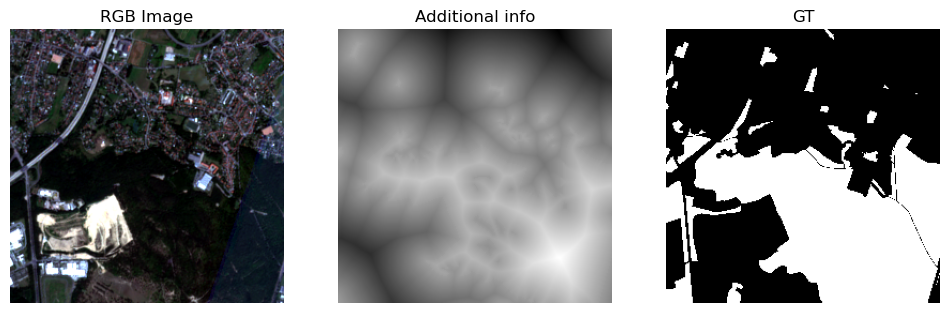

Sample 1:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.49


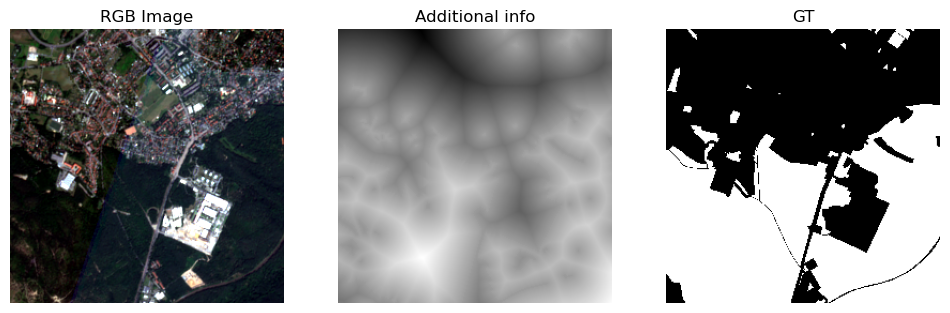

Sample 2:
  Image shape: (14, 256, 256)
  Mask shape: (256, 256)
  Green space percentage: 0.71


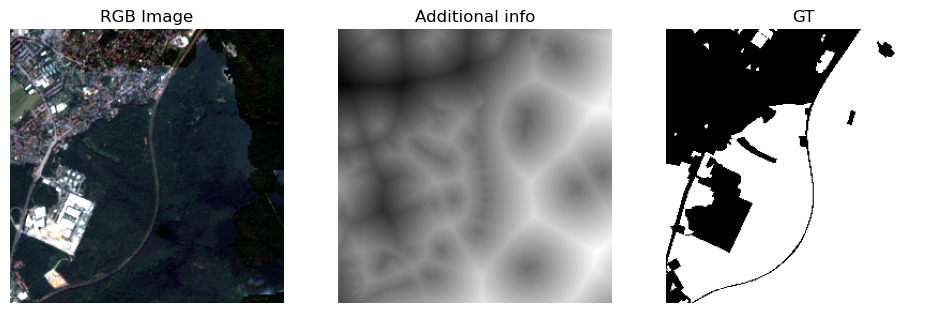

In [9]:
if num_channels > 13:
    visualize_from_torchgeo_dataloader(test_loader, 3, "additional", [13])
else:
    visualize_from_torchgeo_dataloader(test_loader, 3, "original")

# 5. Load model from checkpoint

In [10]:
# Direct loading with the correct channel count
model = CustomSegmentationTask.load_from_checkpoint(
    checkpoint_path,
    in_channels=num_channels,  # Match what's in the checkpoint
)

## Plot train loss and val loss

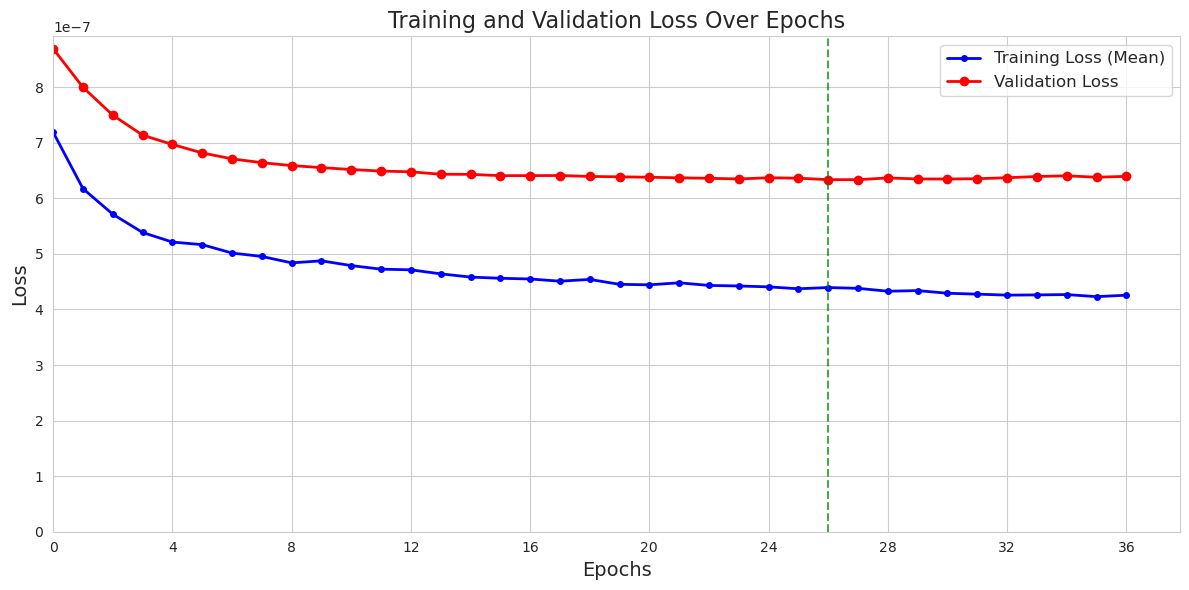

Best model at epoch 26:
  Val Loss: 0.0000
  Val Jaccard: 0.8126


In [11]:
plot_loss_graph(metrics_path, loss_graph_path)

# 6. Evaluate the model

In [12]:
checkpoint_callback = ModelCheckpoint(
    filename="{epoch:02d}-{val_loss:.2f}",
    monitor="val_loss",
    save_top_k=2,  # Save chckpoint with the best validation loss
    # every_n_epochs=5  # Save checkpoint every n epochs
)

In [13]:
early_stopping = EarlyStopping(monitor="val_loss", patience=10)

In [14]:
logger = CSVLogger(logger_path, name=sub_folder_name)

In [15]:
trainer = Trainer(
    max_epochs=epochs,
    deterministic=True,
    accelerator="cpu",
    log_every_n_steps=1,
    callbacks=[checkpoint_callback, early_stopping],
    logger=logger,
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Visualize prediction on test set

In [16]:
trainer.test(model=model, dataloaders=test_loader, ckpt_path=checkpoint_path)

Restoring states from the checkpoint path at ../models/checkpoints/version_8/checkpoints/epoch=27-val_loss=0.00.ckpt
/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:362: The dirpath has changed from '../models/checkpoints/version_8/checkpoints' to '../models/test_result/version_8/checkpoints', therefore `best_model_score`, `kth_best_model_path`, `kth_value`, `last_model_path` and `best_k_models` won't be reloaded. Only `best_model_path` will be reloaded.
Loaded model weights from the checkpoint at ../models/checkpoints/version_8/checkpoints/epoch=27-val_loss=0.00.ckpt
/root/miniforge3/envs/pugs-detection-new/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   test_BinaryAccuracy      0.9531317949295044
 test_BinaryJaccardIndex    0.7258573174476624
        test_loss          6.099783149693394e-07
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_BinaryAccuracy': 0.9531317949295044,
  'test_BinaryJaccardIndex': 0.7258573174476624,
  'test_loss': 6.099783149693394e-07}]

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Sample 0 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 1 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 2 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 3 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.7983424067497253


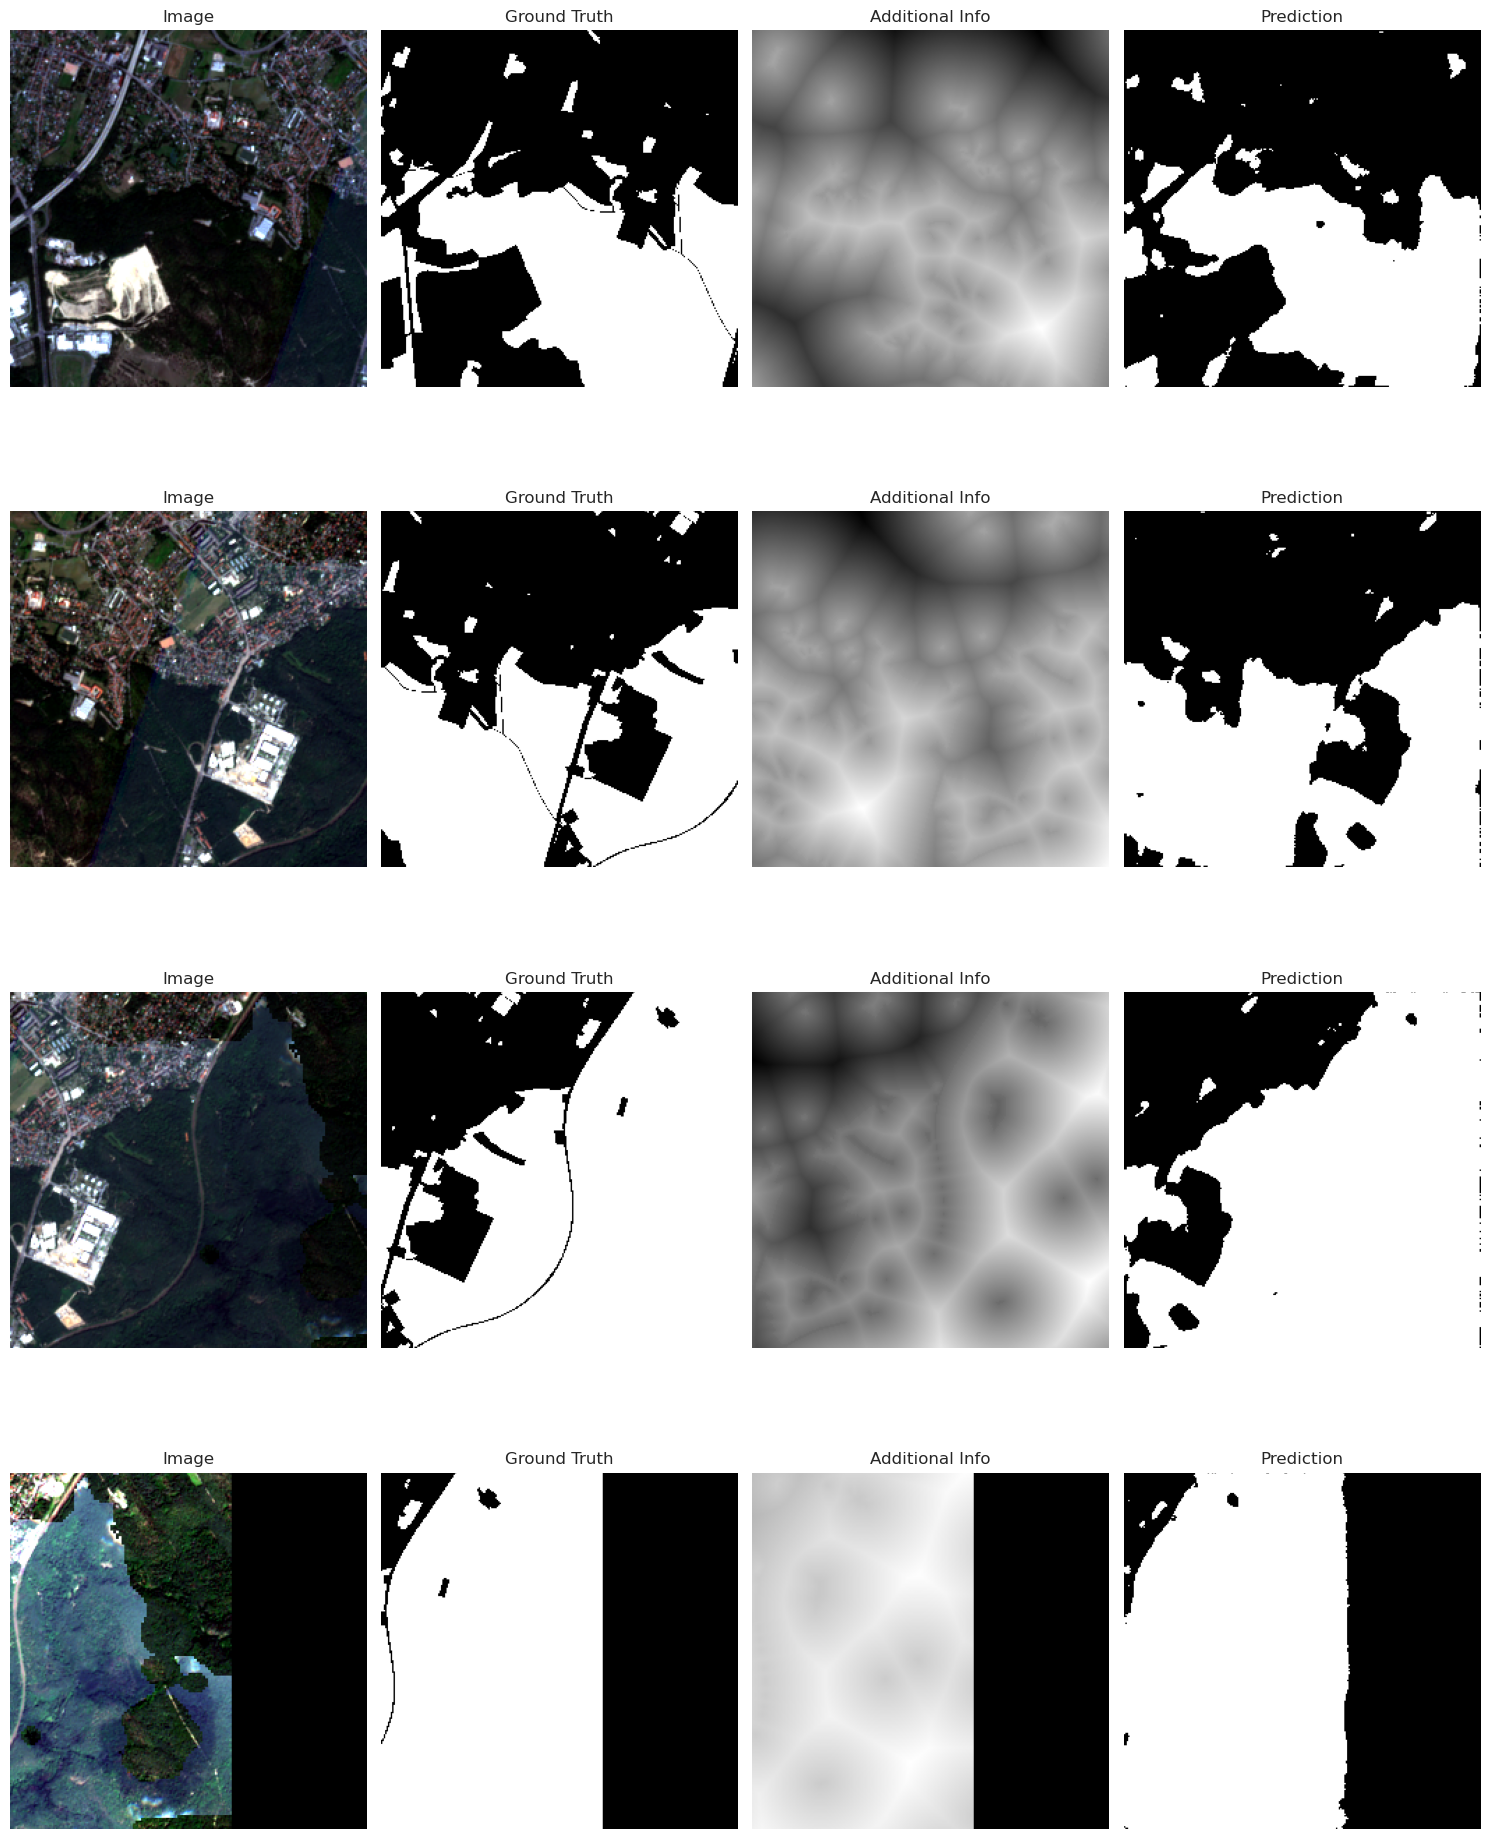

Prediction shape: torch.Size([16, 1, 256, 256])
Mask shape: torch.Size([16, 256, 256])
Sample 0 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 1 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 1.0
Sample 2 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.9967949390411377
Sample 3 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.9246196150779724


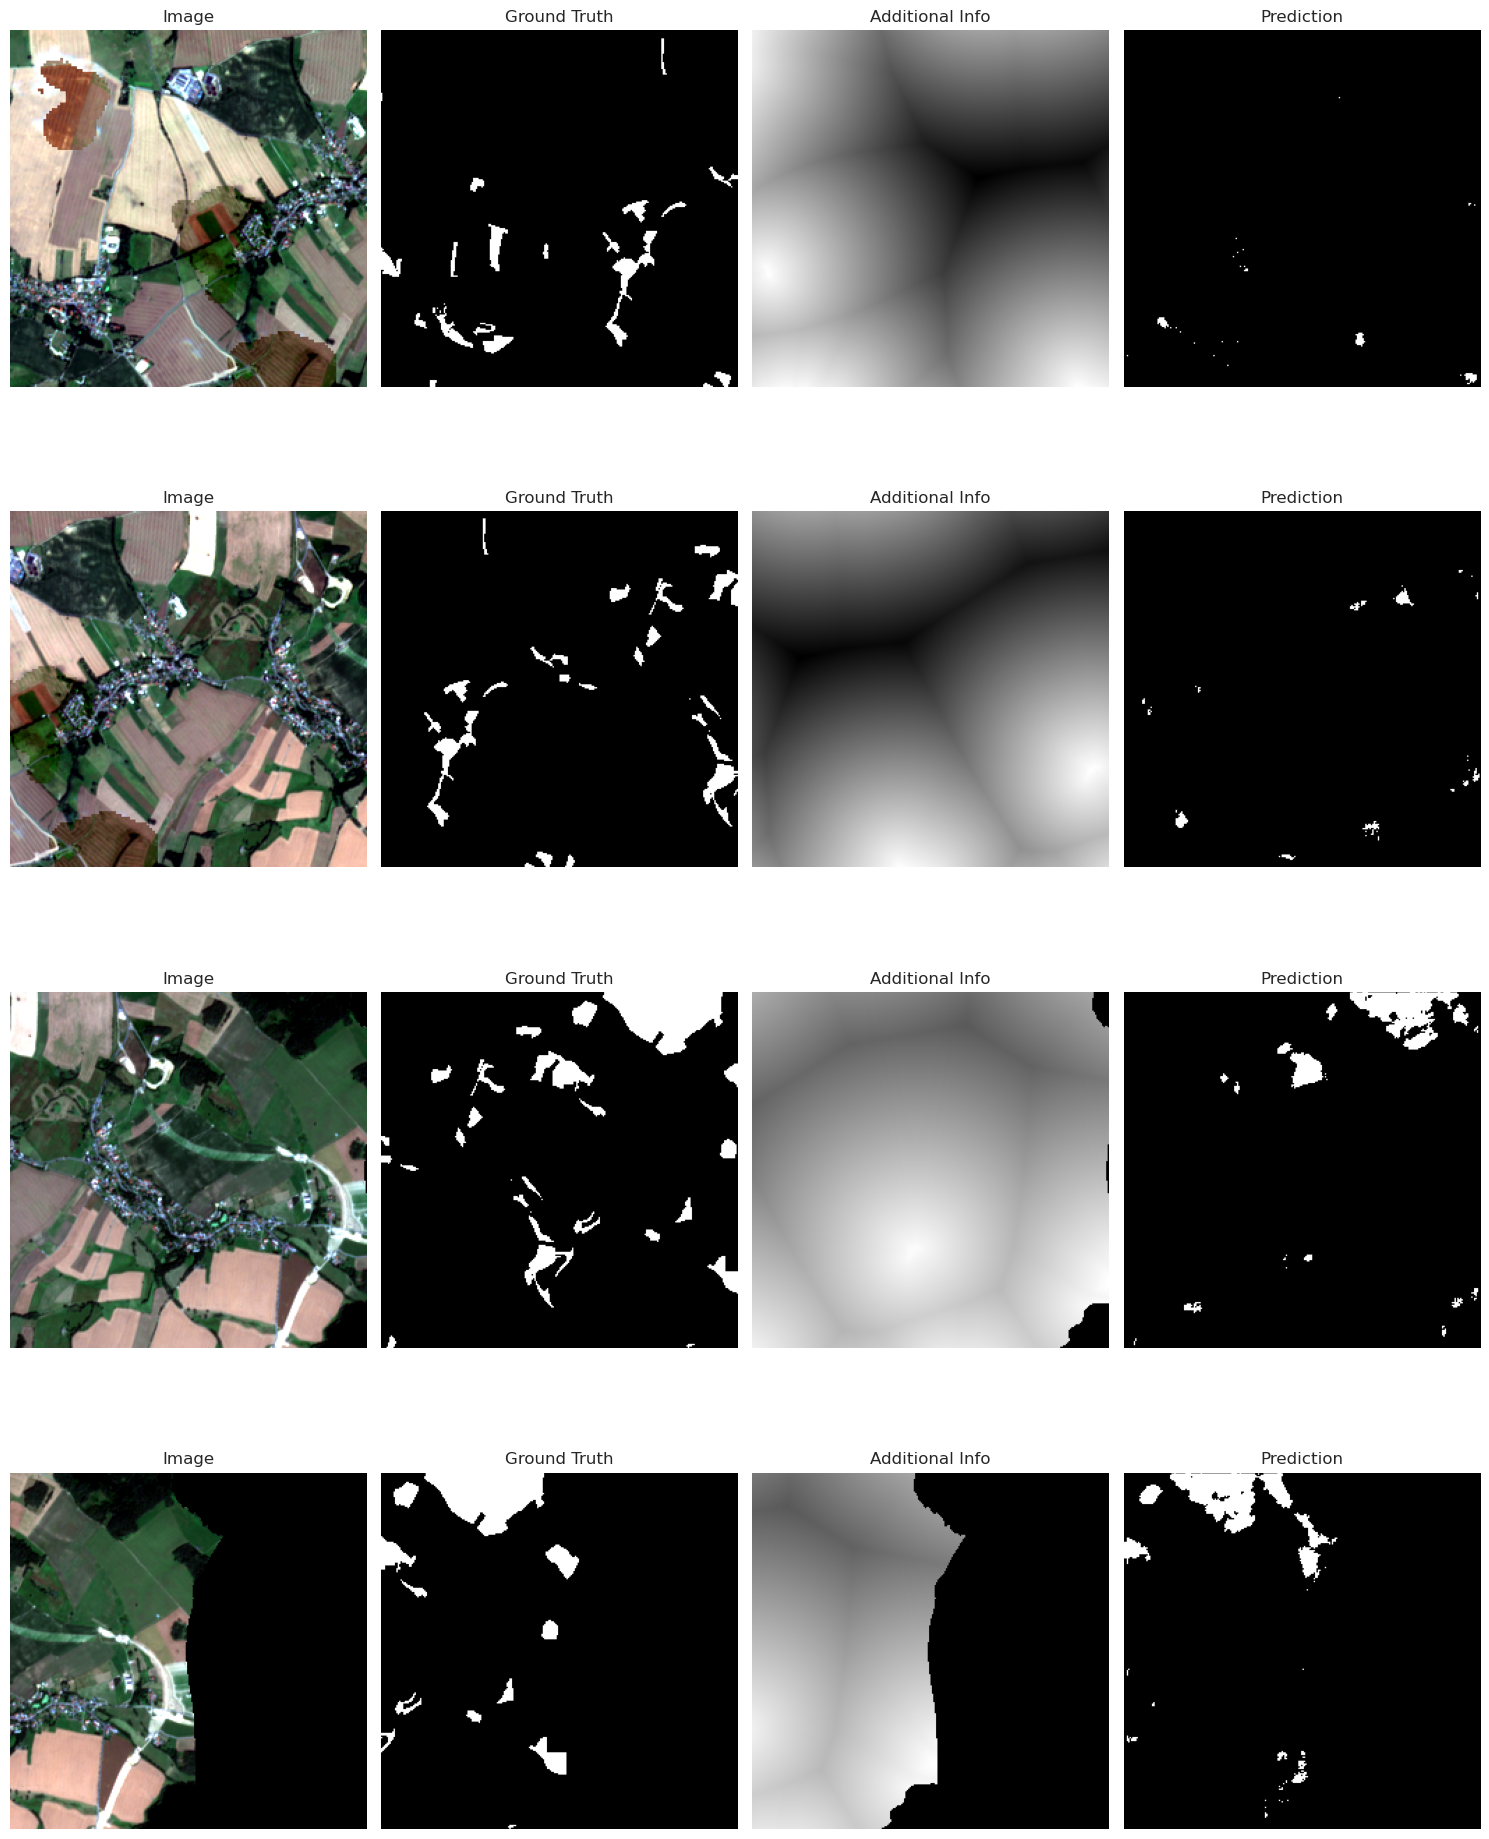

Prediction shape: torch.Size([4, 1, 256, 256])
Mask shape: torch.Size([4, 256, 256])
Sample 0 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.8338661789894104
Sample 1 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.8819354462623569
Sample 2 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.870665431022644
Sample 3 - Image shape: (14, 256, 256), Mask shape: (256, 256), Pred shape: (1, 256, 256)
0.0 0.7889150977134705


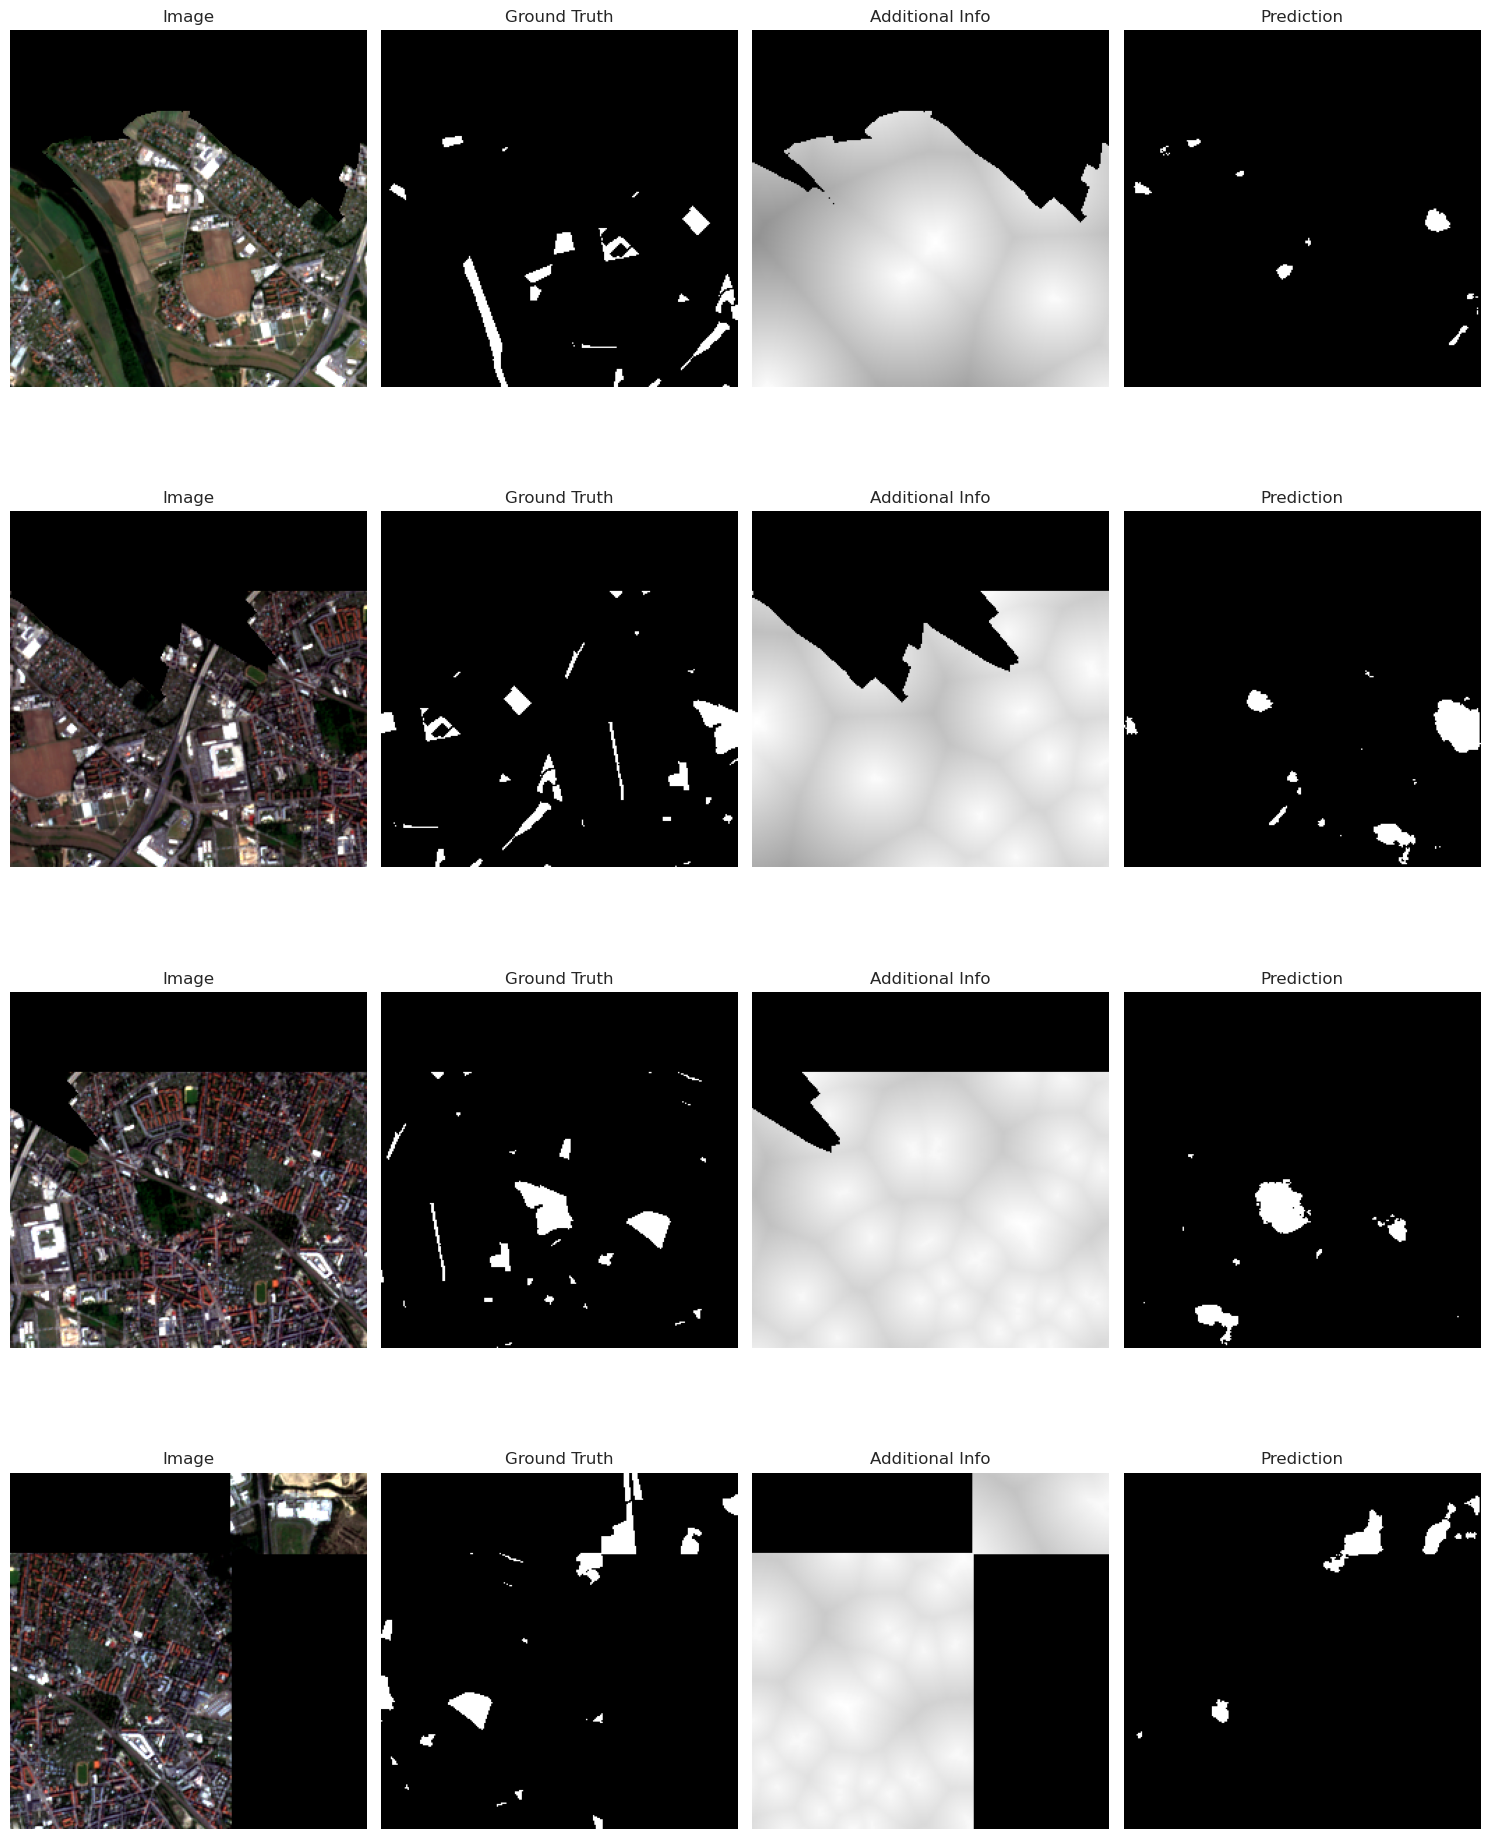

In [17]:
if num_channels > 13:
    visualize_predictions(
        model,
        test_loader,
        mode="additional",
        replace_band_pos=[13],
        output_dir=output_dir,
    )
else:
    visualize_predictions(model, test_loader, mode="original", output_dir=output_dir)

## Confusion matrix

In [18]:
cm = generate_confusion_matrix(model, test_loader)
print("True Negative:", cm[0, 0])
print("False Positive:", cm[0, 1])
print("False Negative:", cm[1, 0])
print("True Positive:", cm[1, 1])

True Negative: 1955944
False Positive: 39234
False Negative: 71342
True Positive: 292776


In [19]:
precision = cm[1, 1] / (cm[1, 1] + cm[0, 1])
recall = cm[1, 1] / (cm[1, 1] + cm[1, 0])
f1 = 2 * precision * recall / (precision + recall)
accuracy = np.sum(np.diag(cm)) / np.sum(cm)
iou = cm[1, 1] / (cm[1, 1] + cm[0, 1] + cm[1, 0])

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"IoU: {iou:.4f}")

Precision: 0.8818
Recall: 0.8041
F1 Score: 0.8412
Accuracy: 0.9531
IoU: 0.7259


In [20]:
metrics = {
    "True Negative": cm[0, 0],
    "False Positive": cm[0, 1],
    "False Negative": cm[1, 0],
    "True Positive": cm[1, 1],
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "Accuracy": accuracy,
    "IoU": iou,
}
df = pd.DataFrame([metrics])
df.to_csv(dump_test_metrics_path, index=False)

# 7. Predict whole area

In [21]:
# Use custom collate function to maintain window_ifo as list of tuples
# so we can easily extract the window coordinates
def custom_collate_fn(batch):
    """Keep window coordinates as a list of tuples instead of tensors"""
    images = torch.stack([torch.from_numpy(item["image"]) for item in batch])
    window_infos = [item["window_info"] for item in batch]

    return {"image": images, "window_info": window_infos}

In [22]:
inference_dataset = PredictedImageDataset(
    image_path_whole_area,
    patch_size=256,
    stride=256,
    band_list_predict=band_list_predict,
)
inference_loader = DataLoader(
    inference_dataset,
    batch_size=4,
    num_workers=4,
    collate_fn=custom_collate_fn,  # Use custom collate function
)

In [23]:
prediction_map = predict_whole_area(model, inference_dataset, inference_loader)

100%|██████████| 25/25 [00:09<00:00,  2.69it/s]


In [24]:
os.makedirs(os.path.dirname(prediction_image_path), exist_ok=True)
# Save the prediction
with rasterio.open(
    prediction_image_path,
    "w",
    driver="GTiff",
    height=inference_dataset.height,
    width=inference_dataset.width,
    count=1,
    dtype=rasterio.int16,
    crs=inference_dataset.crs,
    transform=inference_dataset.transform,
) as dst:
    dst.write(prediction_map[np.newaxis, :, :])

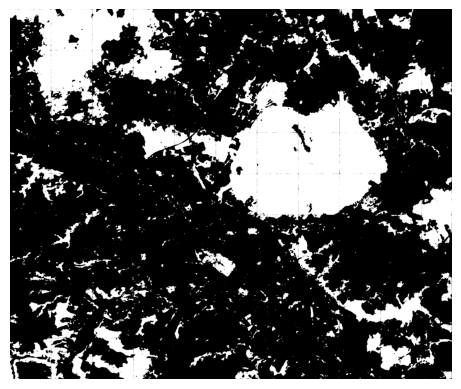

In [25]:
open_image = rasterio.open(prediction_image_path)
image = open_image.read(1)
plt.imshow(image, cmap="gray")
plt.grid(False)
plt.axis("off")
open_image.close()

## Clipped the predicted binary mask to Dresden boundary

In [26]:
dresden_boundary = gpd.read_file(boundary_path)

with rasterio.open(prediction_image_path) as src:
    geoms = [mapping(dresden_boundary.to_crs(src.crs).union_all())]
    out_image, out_transform = mask(src, geoms, crop=True, nodata=-9999)
    out_meta = src.meta.copy()
    out_meta.update(
        {
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
            "nodata": -9999,
        }
    )

os.makedirs(os.path.dirname(clipped_prediction_image_path), exist_ok=True)

with rasterio.open(clipped_prediction_image_path, "w", **out_meta) as dst:
    dst.write(out_image)

(-0.5, 2711.5, 2263.5, -0.5)

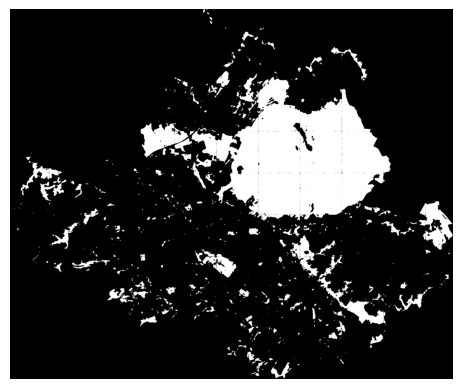

In [27]:
plt.imshow(out_image[0], cmap="gray", vmin=0, vmax=1)
plt.grid(False)
plt.axis("off")

# 8. Save the visualization of prediction and ground truth

In [28]:
viz_coords = [
    (512, 896),
    (512, 1152),
    (768, 1152),
    (896, 1024),
    (896, 1152),
    (896, 1280),
    (1024, 1024),
    (1024, 1280),
    (1024, 1536),
    (1152, 1408),
    (1408, 1280),
    (1536, 1536),
    (2048, 1664)
]

In [29]:
for x, y in tqdm(viz_coords, desc="Generating visualizations", unit="image"):
    try:
        fig = visualize_area(
            original_image_path=clipped_image_path,
            prediction_path=clipped_prediction_image_path,
            ground_truth_path=ground_truth_path,
            x_coord=x,
            y_coord=y,
            window_size=256,
        )

        if output_dir:
            # Save to file
            fig_path = os.path.join(output_dir, f"region_{x}_{y}.png")
            fig.savefig(fig_path, bbox_inches="tight", dpi=300)
            plt.close(fig)
    except Exception as e:
        print(f"Error visualizing window at ({x},{y}): {e}")

print()
print("Complete saving the files")

Generating visualizations: 100%|██████████| 13/13 [00:05<00:00,  2.46image/s]


Complete saving the files


In [30]:
# Usage example with output directory
# visualize_whole_image(
#     original_image_path=image_path,
#     prediction_path=file_output_path,
#     ground_truth_path='../data/processed/ground truth/dresden_pugs_gt.geotiff',
#     window_size=256,
#     stride=128,  # Larger stride to sample fewer areas
#     output_dir='../reports/visualization/region_samples'
# )